# 02 · Feature engineering and PCA

## 0. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

RANDOM_STATE = 42
DATA_DIR = "../data"

## 1. Load clean data

In [5]:
df = pd.read_csv(f"{DATA_DIR}/sessions_clean.csv")
print("Shape:", df.shape)

Shape: (12330, 18)


## 2. Engineered features

In [7]:
# Totals across the three page types
df["total_pages"] = df["Administrative"] + df["Informational"] + df["ProductRelated"]
df["total_duration"] = (df["Administrative_Duration"]
                        + df["Informational_Duration"]
                        + df["ProductRelated_Duration"])

In [8]:
# Average seconds per page (0 if the session has no pages)
df["avg_seconds_per_page"] = (df["total_duration"] / df["total_pages"].replace(0, np.nan)).fillna(0)

In [9]:
# Share of pages that are product pages (0 if the session has no pages)
df["product_page_share"] = (df["ProductRelated"] / df["total_pages"].replace(0, np.nan)).fillna(0)

In [10]:
# Share of time spent on product pages
# If total time is 0, time share is undefined, so we use the page share instead
df["product_time_share"] = (df["ProductRelated_Duration"] / df["total_duration"].replace(0, np.nan))
df["product_time_share"] = df["product_time_share"].fillna(df["product_page_share"])

In [11]:
# Check: how many zero-duration sessions are there, and how many of them viewed product pages?
zero_time = df["total_duration"] == 0
print("Sessions with 0 total duration:   ", zero_time.sum())
print("  ...of which viewed product pages:", (zero_time & (df["ProductRelated"] > 0)).sum())

Sessions with 0 total duration:    720
  ...of which viewed product pages: 702


In [12]:
new_cols = ["total_pages", "total_duration", "avg_seconds_per_page",
            "product_page_share", "product_time_share"]
df[new_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
total_pages,12330.0,34.55,46.51,0.0,8.00,20.00,42.00,746.00
total_duration,12330.0,1310.04,2037.80,0.0,222.00,680.00,1626.91,69921.65
avg_seconds_per_page,12330.0,37.79,43.42,0.0,18.23,29.69,45.42,1411.00
product_page_share,12330.0,0.91,0.14,0.0,0.86,0.96,1.00,1.00
product_time_share,12330.0,0.90,0.17,0.0,0.87,0.98,1.00,1.00


## 3. Log transform

In [14]:
# Columns with heavy right skew and many zeros -> log1p, i.e. log(1 + x), which handles zeros
LOG_COLS = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "total_pages", "total_duration", "avg_seconds_per_page",
]

# Columns that are already rates or shares between 0 and 1 -> no log
NO_LOG_COLS = ["BounceRates", "ExitRates", "product_page_share", "product_time_share"]

X_log = df[LOG_COLS + NO_LOG_COLS].copy()
for col in LOG_COLS:
    X_log[col] = np.log1p(X_log[col])

In [15]:
# Skewness before and after (0 = symmetric; large positive = long right tail)
skew_table = pd.DataFrame({
    "before": df[LOG_COLS].skew(),
    "after_log1p": X_log[LOG_COLS].skew(),
}).round(2)
skew_table

,before,after_log1p
Administrative,1.96,0.57
Administrative_Duration,5.62,0.26
Informational,4.04,2.03
Informational_Duration,7.58,1.92
ProductRelated,4.34,-0.05
ProductRelated_Duration,7.26,-1.42
total_pages,4.19,-0.12
total_duration,7.54,-1.52
avg_seconds_per_page,10.80,-1.52


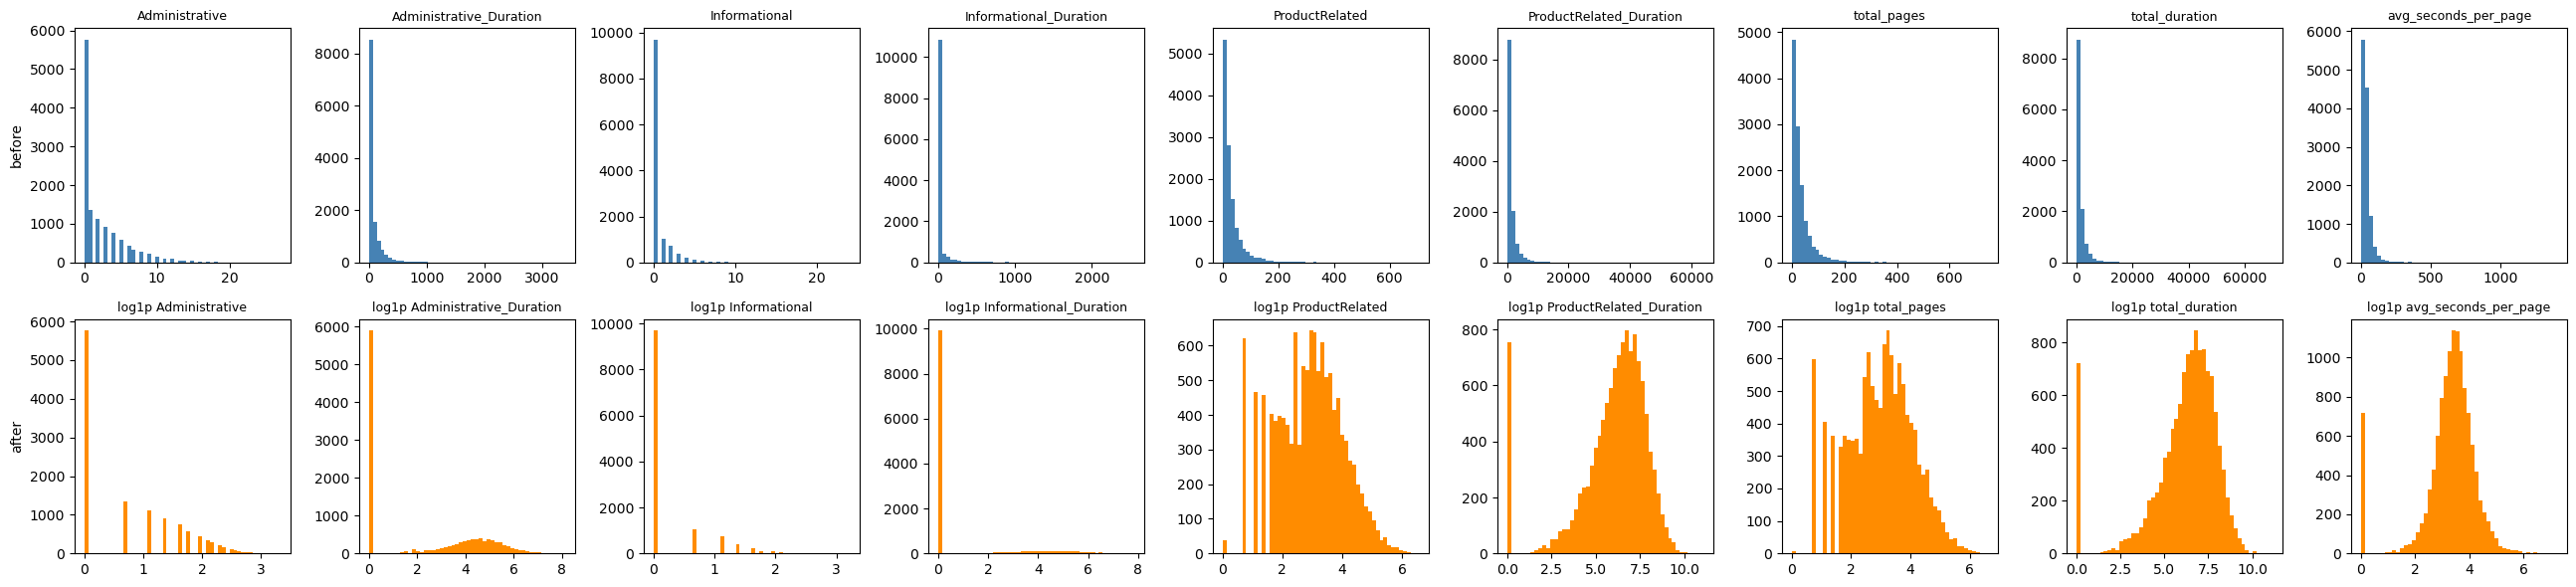

In [16]:
# Distributions before (top row) and after (bottom row) the log transform
fig, axes = plt.subplots(2, len(LOG_COLS), figsize=(26, 6))

for i, col in enumerate(LOG_COLS):
    axes[0, i].hist(df[col], bins=50, color="steelblue")
    axes[0, i].set_title(col, fontsize=9)
    axes[1, i].hist(X_log[col], bins=50, color="darkorange")
    axes[1, i].set_title("log1p " + col, fontsize=9)

axes[0, 0].set_ylabel("before")
axes[1, 0].set_ylabel("after")
plt.tight_layout()
plt.show()

## 4. Check redundancy between features

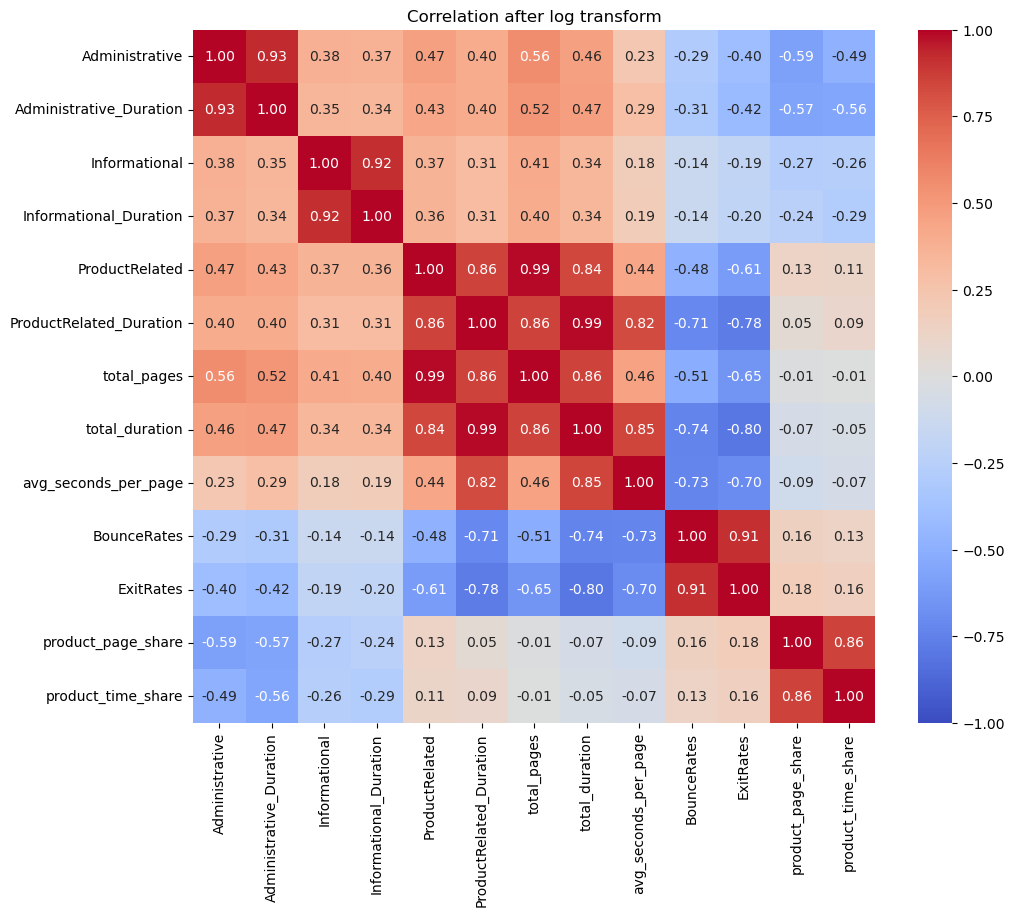

In [18]:
plt.figure(figsize=(11, 9))
sns.heatmap(X_log.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation after log transform")
plt.show()

In [19]:
print("total_pages vs ProductRelated:              ", round(X_log["total_pages"].corr(X_log["ProductRelated"]), 3))
print("total_duration vs ProductRelated_Duration:  ", round(X_log["total_duration"].corr(X_log["ProductRelated_Duration"]), 3))
print("BounceRates vs ExitRates:                   ", round(X_log["BounceRates"].corr(X_log["ExitRates"]), 3))

total_pages vs ProductRelated:               0.989
total_duration vs ProductRelated_Duration:   0.987
BounceRates vs ExitRates:                    0.913


## 5. Final feature set for clustering

In [21]:
# total_pages and total_duration are left out of clustering (kept in df for profiling)
CLUSTER_COLS = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates",
    "avg_seconds_per_page", "product_page_share", "product_time_share",
]

X_cluster = X_log[CLUSTER_COLS]
print("Number of clustering features:", len(CLUSTER_COLS))

Number of clustering features: 11


## 6. Standard scaling

In [23]:
# StandardScaler: subtract the mean and divide by the standard deviation for every column
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_cluster), columns=CLUSTER_COLS)

# Check: every column should now have mean ~0 and std ~1
X_scaled.describe().loc[["mean", "std"]].round(2)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,avg_seconds_per_page,product_page_share,product_time_share
mean,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 7. PCA

In [25]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

variance_table = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(explained))],
    "explained": explained.round(3),
    "cumulative": cumulative.round(3),
})
variance_table

,component,explained,cumulative
0,PC1,0.449,0.449
1,PC2,0.237,0.685
2,PC3,0.140,0.825
3,PC4,0.085,0.910
4,PC5,0.035,0.945
5,PC6,0.023,0.967
6,PC7,0.015,0.983
7,PC8,0.007,0.990
8,PC9,0.006,0.996
9,PC10,0.004,1.000


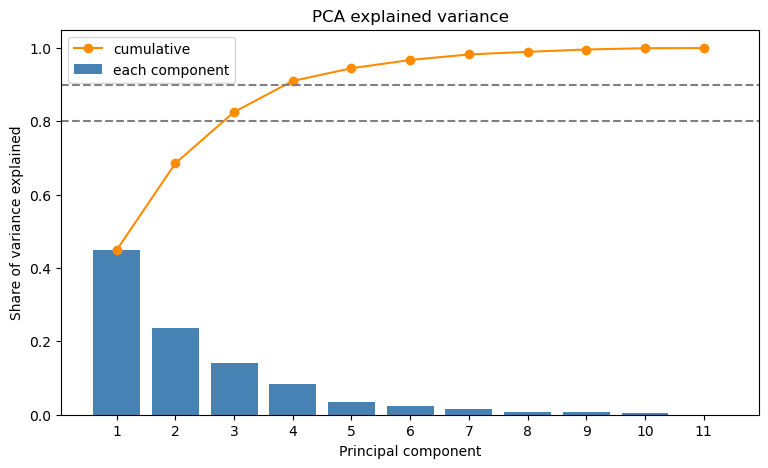

In [26]:
components = np.arange(1, len(explained) + 1)

plt.figure(figsize=(9, 5))
plt.bar(components, explained, color="steelblue", label="each component")
plt.plot(components, cumulative, marker="o", color="darkorange", label="cumulative")
plt.axhline(0.80, color="grey", linestyle="--")
plt.axhline(0.90, color="grey", linestyle="--")
plt.xticks(components)
plt.xlabel("Principal component")
plt.ylabel("Share of variance explained")
plt.title("PCA explained variance")
plt.legend()
plt.show()

In [27]:
N_COMPONENTS = 4   # first 4 components explain about 91% of the variance

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pd.DataFrame(pca.fit_transform(X_scaled),
                     columns=[f"PC{i+1}" for i in range(N_COMPONENTS)])

print("Variance kept:", round(pca.explained_variance_ratio_.sum(), 3))

Variance kept: 0.91


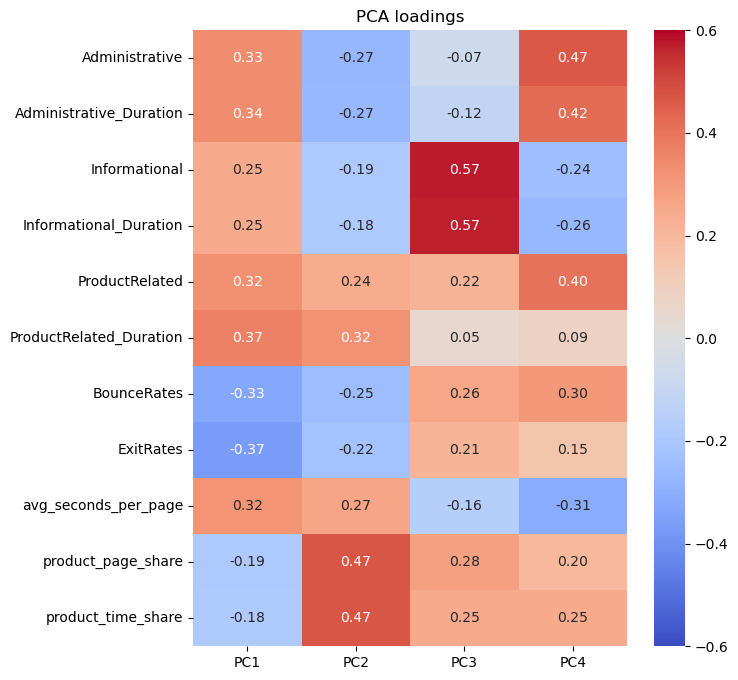

In [28]:
# Loadings: how strongly each original feature points along each component
loadings = pd.DataFrame(pca.components_.T, index=CLUSTER_COLS,
                        columns=[f"PC{i+1}" for i in range(N_COMPONENTS)])

plt.figure(figsize=(7, 8))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", vmin=-0.6, vmax=0.6)
plt.title("PCA loadings")
plt.show()

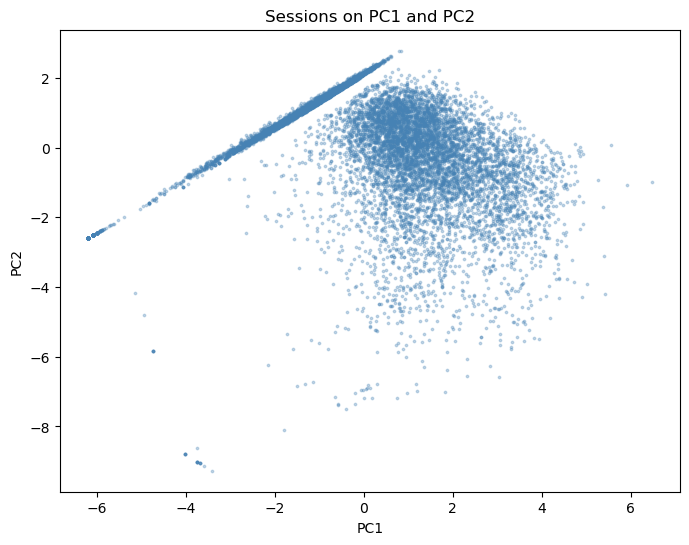

In [29]:
# All sessions on the first two components (no labels: Revenue stays hidden)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca["PC1"], X_pca["PC2"], s=3, alpha=0.3, color="steelblue")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Sessions on PC1 and PC2")
plt.show()

## 8. Save outputs for the next notebooks

In [31]:
df.to_csv(f"{DATA_DIR}/sessions_features.csv", index=False)   # original + engineered columns (for profiling)
X_scaled.to_csv(f"{DATA_DIR}/X_scaled.csv", index=False)       # 11 scaled clustering features
X_pca.to_csv(f"{DATA_DIR}/X_pca.csv", index=False)             # 4 PCA components